# Some Descriptive statistics and Visualizations

In [31]:
import numpy as np
import pandas as pd
import plotly.express as px
import statsmodels.api as sm
import datetime
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression



## Excess Male Mortality (Kobak 2025)

In [2]:
df = pd.read_csv("data/deaths-by-age-gender-region-year-1990-2023.csv.gz")

df

,Region,Year,Age,Gender,Deaths
0,Алтайский край,1990,0-4 лет,f,264
1,Алтайский край,1990,10-14 лет,f,28
2,Алтайский край,1990,15-19 лет,f,63
3,Алтайский край,1990,20-24 лет,f,67
4,Алтайский край,1990,25-29 лет,f,94
...,...,...,...,...,...
116691,Ярославская область,2023,75-79 лет,m,681
116692,Ярославская область,2023,80-84 лет,m,727
116693,Ярославская область,2023,85 и более,m,733
116694,Ярославская область,2023,Неизвестно,m,5


In [3]:

def male_excess(region, year, df, horizon=5):
    LinReg = LinearRegression()
    agegroups = ['15-19 лет', '20-24 лет', '25-29 лет',
                 '30-34 лет', '35-39 лет', '40-44 лет', 
                 '45-49 лет', '50-54 лет', '55-59 лет']
    
    ex_male = []

    for age in agegroups: 
        male = df[
            (df.Region == region) & 
            (df.Age == age) & 
            (df.Gender == 'm') & 
            (df.Year <= min(year, 2019)) 
        ][['Year', 'Deaths']].values

        female = df[
            (df.Region == region) & 
            (df.Age == age) & 
            (df.Gender == 'f') & 
            (df.Year <= min(year, 2019))
        ][['Year', 'Deaths']].values


        male_deaths = male[-(horizon + 1):-1, 1]
        female_deaths = female[-(horizon + 1):-1, 1]
        years = male[-(horizon + 1):-1, 0].reshape(-1, 1)

        valid = female_deaths > 0
        male_deaths = male_deaths[valid]
        female_deaths = female_deaths[valid]
        years = years[valid]

        ratios = male_deaths / female_deaths
        LinReg.fit(years, ratios.reshape(-1, 1))
        ratio_hat = LinReg.predict([[year]])[0][0]
        male_excess = male[-1,1] - ratio_hat * female[-1,1]
        ex_male.append(male_excess)

    return ex_male

In [4]:
results = []

for region in df.Region.unique():
    for year in range(2022, 2024):
        ex = male_excess(region, year, df)
        total_all = sum(ex)
        total_15_49 = sum(ex[:7])  

        results.append({
            'Region': region,
            'Year': year,
            'ExcessByAge': ex,
            'TotalExcess_15_49': total_15_49,
            'TotalExcess_15_59': total_all
        })

results_df = pd.DataFrame(results)
exclude = ['Российская Федерация','Архангельская область', 'Тюменская область']
results_df = results_df[~results_df['Region'].isin(exclude)]



# Normalising by population

In [5]:
male_pop = pd.read_excel("data/male_pop.xls")
male_pop.columns.values[0:2] = ['age', 'Region']
male_pop['Region'] = male_pop['Region'].str.strip()
agegroups = ['15-19 лет', '20-24 лет', '25-29 лет',
             '30-34 лет', '35-39 лет', '40-44 лет', 
             '45-49 лет', '50-54 лет',  '55-59 лет']

male_pop_long = male_pop.melt(
    id_vars=['age', 'Region'],
    var_name='year',
    value_name='male_population'
)

male_pop_long['year'] = pd.to_numeric(male_pop_long['year'], errors='coerce')
male_pop_long = male_pop_long[male_pop_long['age'].isin(agegroups)]
male_pop_long = male_pop_long.dropna(subset=['male_population'])
male_pop_long = male_pop_long[male_pop_long['year'].isin([2022, 2023])]
male_pop = male_pop_long.groupby(['Region', 'year'], as_index=False)['male_population'].sum()

male_pop_long['year'] = pd.to_numeric(male_pop_long['year'], errors='coerce')
male_pop_long = male_pop_long[male_pop_long['age'].isin(agegroups[:7])]
male_pop_long = male_pop_long.dropna(subset=['male_population'])
male_pop_long = male_pop_long[male_pop_long['year'].isin([2022, 2023])]
male_pop1559 = male_pop_long.groupby(['Region', 'year'], as_index=False)['male_population'].sum()
male_pop = male_pop.merge(male_pop1559, on=['Region', 'year'], how='left')
male_pop.columns = ['Region', 'Year', 'male_pop1559', 'male_pop1549']
male_pop

,Region,Year,male_pop1559,male_pop1549
0,Алтайский край,2022,584819.0,466463.0
1,Алтайский край,2023,576369.0,460639.0
2,Амурская область,2022,228799.0,187638.0
3,Амурская область,2023,226425.0,185337.0
4,Архангельская область,2022,288859.0,229772.0
...,...,...,...,...
187,Южный федеральный округ (с 29.07.2016),2023,4811907.0,3836382.0
188,Ямало-Ненецкий автономный округ (Тюменская обл...,2022,167641.0,134869.0
189,Ямало-Ненецкий автономный округ (Тюменская обл...,2023,165779.0,133165.0
190,Ярославская область,2022,335297.0,265549.0


In [6]:
region_name_mapping = {
    'Архангельская область (кроме Ненецкого автономного округа)': 'Архангельская область без АО',
    'Ненецкий автономный округ (Архангельская область)': 'Ненецкий АО',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Город Москва столица Российской Федерации город федерального значения': 'Москва',
    'Город Санкт-Петербург город федерального значения': 'Санкт-Петербург',
    'Город федерального значения Севастополь': 'Севастополь',
    'Еврейская автономная область': 'Еврейская АО',
    'Кабардино-Балкарская Республика': 'Кабардино-Балкария',
    'Карачаево-Черкесская Республика': 'Карачаево-Черкесия',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Саха (Якутия)': 'Якутия',
    'Республика Северная Осетия-Алания': 'Северная Осетия',
    'Республика Татарстан (Татарстан)': 'Республика Татарстан',
    'Чувашская Республика - Чувашия': 'Чувашская Республика',
    'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)': 'Тюменская область без АО',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)': 'Ханты-Мансийский АО',
    'Ямало-Ненецкий автономный округ (Тюменская область)': 'Ямало-Hенецкий АО',
    'Чукотский автономный округ': 'Чукотский АО',
}

male_pop['Region'] = male_pop['Region'].replace(region_name_mapping)
df_merged = male_pop.merge(results_df, on=['Region', 'Year'], how='left')
df_merged = df_merged.dropna()
df_merged['ex_per100k_1549'] = df_merged['TotalExcess_15_49'] / df_merged['male_pop1549'] * 100_000
df_merged['ex_per100k_1559'] = df_merged['TotalExcess_15_59'] / df_merged['male_pop1559'] * 100_000
df_merged

,Region,Year,male_pop1559,male_pop1549,ExcessByAge,TotalExcess_15_49,TotalExcess_15_59,ex_per100k_1549,ex_per100k_1559
0,Алтайский край,2022,584819.0,466463.0,"[-1.271708683472525, 31.576520201478672, 39.46...",163.254315,111.945185,34.998342,19.141852
1,Алтайский край,2023,576369.0,460639.0,"[2.1095658263308223, 36.495800021434434, 52.21...",218.126747,171.041177,47.353078,29.675638
2,Амурская область,2022,228799.0,187638.0,"[-40.28679738562198, -1.7303030303029914, 36.4...",226.897197,174.851793,120.922839,76.421572
3,Амурская область,2023,226425.0,185337.0,"[-45.43882352941273, 1.8147186147187995, 45.58...",292.867845,222.919167,158.019092,98.451658
6,Архангельская область без АО,2022,276243.0,219392.0,"[-47.066096256685796, 33.84784313725322, 42.95...",87.478258,-389.551858,39.873039,-141.017821
...,...,...,...,...,...,...,...,...,...
185,Чукотский АО,2023,16096.0,12838.0,"[-2.1000000000000227, 7.0, 5.411428571428701, ...",-11.057973,3.129891,-86.134698,19.445148
188,Ямало-Hенецкий АО,2022,167641.0,134869.0,"[-6.85396825396856, 15.526785714285666, -83.81...",-108.231758,-241.992308,-80.249545,-144.351506
189,Ямало-Hенецкий АО,2023,165779.0,133165.0,"[-8.231746031746297, 17.44940476190459, -90.90...",-118.748685,-263.507656,-89.174096,-158.951167
190,Ярославская область,2022,335297.0,265549.0,"[-4.988888888888965, 64.59944055944288, -12.90...",439.367046,595.103137,165.456110,177.485375


In [7]:
pivot_df = df_merged.pivot(index='Region', columns='Year', values='ex_per100k_1549').reset_index()


fig = px.scatter(
    x=pivot_df[2022],
    y=pivot_df[2023],
    hover_name=pivot_df['Region'],
    title="Excess Male Mortality: 2022 vs 2023",
    labels={"x": "Excess in 2022", "y": "Excess in 2023"},
    width=800, height=700
)

fig.show()



# Crowdsourced data on mortality 2022-2023 (BBC and Mediazona)


In [8]:
daily = pd.read_csv('data/daily.csv')
daily = daily.rename(columns={'region': "Region"})
contract = ['автомобильные', 'артиллерия', 'ВДВ', 'военмед', 'военные пилоты',
       'войска связи', 'войсковая ПВО', 'инженерные войска', 'МВД','морпехи', 'моряки',
       'мотострелковые войска', 'наземные авиаслужбы', 'нацгвардия',
       'РХБЗ', 'спецназ', 'танковые войска', 'ФСБ', 
       'другие войска', 'ЖД', 'военная полиция', 'СК', 'ФСО']

#military branch
daily["total"] = 1
daily["drafted"] = daily["pmc"] = daily["volunteers"] = daily["prisoners"] = daily['contract'] = 0
daily.loc[daily['branch'] == 'добровольцы', 'volunteers'] = 1
daily.loc[daily['branch'] == 'мобилизованные', 'drafted'] = 1
daily.loc[daily['branch'] == 'ЧВК', 'pmc'] = 1
daily.loc[daily['branch'] == 'заключенные', 'prisoners'] = 1
daily.loc[daily['branch'].isin(contract), 'contract'] = 1



In [9]:
df_annual = daily.copy()
df_annual = df_annual[df_annual['death_month'].notna()]
df_annual['Year'] = df_annual['death_month'].astype(str).str[-4:].astype(int)
df_annual['non_slavic'] = 1 - df_annual['slavic']
casualty_cols = ['total', 'drafted', 'pmc', 'volunteers', 'prisoners', 'contract', 'slavic', 'non_slavic']
annual = df_annual.groupby(['Region', 'Year'])[casualty_cols].sum().reset_index()
annual

,Region,Year,total,drafted,pmc,volunteers,prisoners,contract,slavic,non_slavic
0,Алтайский край,2022,400,0,14,33,8,291,376,24
1,Алтайский край,2023,677,80,40,120,218,51,631,46
2,Алтайский край,2024,985,91,0,425,62,137,921,64
3,Алтайский край,2025,30,0,0,28,0,2,28,2
4,Амурская область,2022,100,0,5,25,0,67,91,9
...,...,...,...,...,...,...,...,...,...,...
340,Ямало-Ненецкий автономный округ,2025,38,6,0,15,0,1,26,12
341,Ярославская область,2022,71,0,0,14,36,21,68,3
342,Ярославская область,2023,194,59,8,44,46,10,190,4
343,Ярославская область,2024,230,25,5,89,0,35,222,8


In [10]:
region_name_mapping = {
    'Архангельская область': 'Архангельская область без АО',
    'Ненецкий автономный округ': 'Ненецкий АО',
    'Еврейская автномная область': 'Еврейская АО',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Еврейская автономная область': 'Еврейская АО',
    'Кабардино-Балкарская Республика': 'Кабардино-Балкария',
    'Республика Карачаево-Черкесия': 'Карачаево-Черкесия',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Саха (Якутия)': 'Якутия',
    'Республика Северная Осетия-Алания': 'Северная Осетия',
    'Тюменская область': 'Тюменская область без АО',
    'Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский АО',
    'Ямало-Ненецкий автономный округ': 'Ямало-Hенецкий АО',
    'Чукотский автономный округ': 'Чукотский АО',
}

annual['Region'] = annual['Region'].replace(region_name_mapping)



In [11]:
df_merged = df_merged.merge(annual, on = ["Region", 'Year'] , how = 'left')
df_merged

,Region,Year,male_pop1559,male_pop1549,ExcessByAge,TotalExcess_15_49,TotalExcess_15_59,ex_per100k_1549,ex_per100k_1559,total,drafted,pmc,volunteers,prisoners,contract,slavic,non_slavic
0,Алтайский край,2022,584819.0,466463.0,"[-1.271708683472525, 31.576520201478672, 39.46...",163.254315,111.945185,34.998342,19.141852,400.0,0.0,14.0,33.0,8.0,291.0,376.0,24.0
1,Алтайский край,2023,576369.0,460639.0,"[2.1095658263308223, 36.495800021434434, 52.21...",218.126747,171.041177,47.353078,29.675638,677.0,80.0,40.0,120.0,218.0,51.0,631.0,46.0
2,Амурская область,2022,228799.0,187638.0,"[-40.28679738562198, -1.7303030303029914, 36.4...",226.897197,174.851793,120.922839,76.421572,100.0,0.0,5.0,25.0,0.0,67.0,91.0,9.0
3,Амурская область,2023,226425.0,185337.0,"[-45.43882352941273, 1.8147186147187995, 45.58...",292.867845,222.919167,158.019092,98.451658,282.0,37.0,0.0,57.0,87.0,55.0,267.0,15.0
4,Архангельская область без АО,2022,276243.0,219392.0,"[-47.066096256685796, 33.84784313725322, 42.95...",87.478258,-389.551858,39.873039,-141.017821,168.0,15.0,0.0,26.0,53.0,52.0,160.0,8.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Чукотский АО,2023,16096.0,12838.0,"[-2.1000000000000227, 7.0, 5.411428571428701, ...",-11.057973,3.129891,-86.134698,19.445148,55.0,19.0,0.0,21.0,11.0,4.0,46.0,9.0
166,Ямало-Hенецкий АО,2022,167641.0,134869.0,"[-6.85396825396856, 15.526785714285666, -83.81...",-108.231758,-241.992308,-80.249545,-144.351506,36.0,0.0,0.0,8.0,0.0,7.0,31.0,5.0
167,Ямало-Hенецкий АО,2023,165779.0,133165.0,"[-8.231746031746297, 17.44940476190459, -90.90...",-118.748685,-263.507656,-89.174096,-158.951167,146.0,6.0,4.0,22.0,68.0,30.0,106.0,40.0
168,Ярославская область,2022,335297.0,265549.0,"[-4.988888888888965, 64.59944055944288, -12.90...",439.367046,595.103137,165.456110,177.485375,71.0,0.0,0.0,14.0,36.0,21.0,68.0,3.0


In [12]:
##per capita

df_merged["Drafted_pc"] = df_merged["drafted"]/df_merged["male_pop1549"]*100000
df_merged["Total_pc"] = df_merged["total"]/df_merged["male_pop1549"]*1000000
df_merged["Volunteers_pc"] = df_merged["volunteers"]/df_merged["male_pop1549"]*100000
df_merged["Prisoners_pc"] = df_merged["prisoners"]/df_merged["male_pop1549"]*100000
df_merged["Contract_pc"] = df_merged['contract']/df_merged["male_pop1549"]*100000
df_merged["PMC_pc"] = df_merged["pmc"]/df_merged["male_pop1549"]*100000
df_merged["slavic_pc"] = df_merged["slavic"]/df_merged["male_pop1549"]*100000
df_merged["non_slavic_pc"] = df_merged["non_slavic"] /df_merged["male_pop1549"]*100000

In [13]:

fig = px.scatter(
    df_merged,
    x='ex_per100k_1549',
    y='Total_pc',
    hover_name='Region',
    title="War Fatalities per 100k of Male population aged 18-59 by source of estimation",
    labels={"ex_per100k_1549": "Excess in mortality", "Total_pc": "Crowdsourced data"},
    width=800, height=700
)



fig.show()


## Adding excessive nuptiality in 09.2022-11.2022 as a proxy for draft (Mediazona)

In [14]:
nup = pd.read_excel("data/data.xls", header=[0, 1])
nup = nup.drop(columns = nup.columns[0])
names = pd.read_excel("data/data.xls").iloc[1:,0]
nup.index = names
nup.index.name = "Region"
nup.columns = pd.MultiIndex.from_tuples(nup.columns)

nup

2006                                        \
                             январь февраль   март  апрель    май    июнь   
Region                                                                      
Белгородская область          686.0   751.0  639.0   809.0  427.0  1240.0   
Брянская область              471.0   625.0  554.0   665.0  239.0  1062.0   
Владимирская область          473.0   623.0  601.0   779.0  292.0  1098.0   
Воронежская область           945.0  1042.0  785.0  1254.0  623.0  1544.0   
Ивановская область            347.0   438.0  447.0   529.0  206.0   786.0   
...                             ...     ...    ...     ...    ...     ...   
Амурская область              317.0   442.0  613.0   604.0  218.0   688.0   
Магаданская область            89.0    99.0  126.0   127.0   47.0   165.0   
Сахалинская область           248.0   282.0  333.0   364.0  185.0   422.0   
Еврейская автономная область   78.0    67.0  119.0   114.0   50.0   171.0   
Чукотский автономный округ     11.0    42.0   50.0    41.0   36.0    38.0   

                                                               ...   2024  \
                                июль  август сентябрь октябрь  ... апрель   
Region                                                         ...          
Белгородская область          1581.0  1787.0   1787.0  1140.0  ...    560   
Брянская область              1349.0  1596.0   1427.0   765.0  ...    370   
Владимирская область          1397.0  1689.0   1707.0   884.0  ...    436   
Воронежская область           2121.0  2320.0   2852.0  1434.0  ...    815   
Ивановская область            1062.0  1299.0   1198.0   706.0  ...    321   
...                              ...     ...      ...     ...  ...    ...   
Амурская область               756.0   982.0    808.0   580.0  ...    502   
Магаданская область            162.0   123.0    163.0   151.0  ...     77   
Сахалинская область            437.0   541.0    547.0   456.0  ...    262   
Еврейская автономная область   128.0   199.0    169.0   169.0  ...    100   
Чукотский автономный округ      65.0    31.0     37.0    31.0  ...     28   

                                                                              \
                              май  июнь  июль август сентябрь октябрь ноябрь   
Region                                                                         
Белгородская область          522  1019  1011   1328      889     697    588   
Брянская область              264   754   796    966      597     438    378   
Владимирская область          378   870  1026   1161      800     590    496   
Воронежская область           935  1687  1837   2260     1537    1231    889   
Ивановская область            266   554   625    789      507     400    357   
...                           ...   ...   ...    ...      ...     ...    ...   
Амурская область              348   559   675    720      543     487    400   
Магаданская область            48    89    83     84       79      68     61   
Сахалинская область           210   334   370    464      409     333    284   
Еврейская автономная область   67   122   105    124       55     106     90   
Чукотский автономный округ     22    25    20     29       28      29     31   

                                       2025  
                             декабрь январь  
Region                                       
Белгородская область             482    558  
Брянская область                 370    352  
Владимирская область             426    385  
Воронежская область              723    870  
Ивановская область               303    272  
...                              ...    ...  
Амурская область                 428    304  
Магаданская область               70     57  
Сахалинская область              266    202  
Еврейская автономная область      67     70  
Чукотский автономный округ        26     28  

[87 rows x 229 columns]

In [15]:
nup_long = nup.stack(level=[0, 1]).reset_index()
nup_long.columns = ['Region', 'Year', 'Month', 'Marriages']
month_map = {
    'январь': 1, 'февраль': 2, 'март': 3, 'апрель': 4, 'май': 5, 'июнь': 6,
    'июль': 7, 'август': 8, 'сентябрь': 9, 'октябрь': 10, 'ноябрь': 11, 'декабрь': 12
}
nup_long['Month'] = nup_long['Month'].map(month_map)
nup_long['Year'] = nup_long['Year'].astype(int)

nup_long

C:\Users\Robert_Beta\AppData\Local\Temp\ipykernel_9460\2606162799.py:1: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.



,Region,Year,Month,Marriages
0,Белгородская область,2006,1,686.0
1,Белгородская область,2006,2,751.0
2,Белгородская область,2006,3,639.0
3,Белгородская область,2006,4,809.0
4,Белгородская область,2006,5,427.0
...,...,...,...,...
19510,Чукотский автономный округ,2024,9,28.0
19511,Чукотский автономный округ,2024,10,29.0
19512,Чукотский автономный округ,2024,11,31.0
19513,Чукотский автономный округ,2024,12,26.0


In [16]:
baseline = nup_long[nup_long['Year'].between(2015, 2019) & nup_long["Month"].between(9,11)]
expected = (
    baseline
    .groupby(['Region', 'Month'])['Marriages']
    .mean()
    .reset_index()
    .rename(columns={'Marriages': 'Expected'})
)

expected = expected.merge(nup_long[nup_long["Year"] == 2022], on = ['Region', 'Month'], how = 'left')
expected["Excess"] = expected["Marriages"] - expected["Expected"]
expected

,Region,Month,Expected,Year,Marriages,Excess
0,Архангельская область (кроме Ненец...,9,738.2,2022,785.0,46.8
1,Архангельская область (кроме Ненец...,10,518.0,2022,860.0,342.0
2,Архангельская область (кроме Ненец...,11,482.6,2022,778.0,295.4
3,Ненецкий автономный округ (Арханге...,9,23.6,2022,20.0,-3.6
4,Ненецкий автономный округ (Арханге...,10,17.6,2022,43.0,25.4
...,...,...,...,...,...,...
256,Чукотский автономный округ,10,29.8,2022,77.0,47.2
257,Чукотский автономный округ,11,35.0,2022,48.0,13.0
258,Ярославская область,9,973.2,2022,952.0,-21.2
259,Ярославская область,10,586.2,2022,1020.0,433.8


In [17]:
mar_ex = (
    expected
    .groupby(["Region"])["Excess"]
    .sum()
)
mar_ex.name = "Excessive Marriages"
mar_ex = mar_ex.reset_index()
mar_ex


,Region,Excessive Marriages
0,Архангельская область (кроме Ненец...,684.2
1,Ненецкий автономный округ (Арханге...,22.4
2,Тюменская область (кроме Ханты-Ман...,1886.4
3,Ханты-Мансийский автономный округ ...,868.8
4,Ямало-Ненецкий автономный округ (Т...,386.2
...,...,...
82,Челябинская область,2541.8
83,Чеченская Республика,-885.6
84,Чувашская Республика - Чувашия,185.6
85,Чукотский автономный округ,69.4


# Excessive Nuptiality vs Casualties 

In [18]:
region_name_mapping = {
    'Архангельская область (кроме Ненецкого автономного округа)': 'Архангельская область без АО',
    'Ненецкий автономный округ (Архангельская область)': 'Ненецкий АО',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Город Москва столица Российской Федерации город федерального значения': 'Москва',
    'Город Санкт-Петербург город федерального значения': 'Санкт-Петербург',
    'Город федерального значения Севастополь': 'Севастополь',
    'Еврейская автономная область': 'Еврейская АО',
    'Кабардино-Балкарская Республика': 'Кабардино-Балкария',
    'Карачаево-Черкесская Республика': 'Карачаево-Черкесия',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Саха (Якутия)': 'Якутия',
    'Республика Северная Осетия-Алания': 'Северная Осетия',
    'Республика Татарстан (Татарстан)': 'Республика Татарстан',
    'Чувашская Республика - Чувашия': 'Чувашская Республика',
    'Тюменская область (кроме Ханты-Мансийского автономного округа-Югры и Ямало-Ненецкого автономного округа)': 'Тюменская область без АО',
    'Ханты-Мансийский автономный округ - Югра (Тюменская область)': 'Ханты-Мансийский АО',
    'Ямало-Ненецкий автономный округ (Тюменская область)': 'Ямало-Hенецкий АО',
    'Чукотский автономный округ': 'Чукотский АО',
}

mar_ex['Region'] = mar_ex['Region'].str.strip().replace(region_name_mapping)



In [19]:
df_full = df_merged.merge(mar_ex, on = "Region", how = "left")
df_full["ex_nup_per100k"] = df_full["Excessive Marriages"]/df_full["male_pop1549"]*100000
df_full

,Region,Year,male_pop1559,male_pop1549,ExcessByAge,TotalExcess_15_49,TotalExcess_15_59,ex_per100k_1549,ex_per100k_1559,total,...,Drafted_pc,Total_pc,Volunteers_pc,Prisoners_pc,Contract_pc,PMC_pc,slavic_pc,non_slavic_pc,Excessive Marriages,ex_nup_per100k
0,Алтайский край,2022,584819.0,466463.0,"[-1.271708683472525, 31.576520201478672, 39.46...",163.254315,111.945185,34.998342,19.141852,400.0,...,0.000000,857.517102,7.074516,1.715034,62.384369,3.001310,80.606608,5.145103,2007.6,430.387834
1,Алтайский край,2023,576369.0,460639.0,"[2.1095658263308223, 36.495800021434434, 52.21...",218.126747,171.041177,47.353078,29.675638,677.0,...,17.367179,1469.697529,26.050769,47.325563,11.071577,8.683590,136.983625,9.986128,2007.6,435.829359
2,Амурская область,2022,228799.0,187638.0,"[-40.28679738562198, -1.7303030303029914, 36.4...",226.897197,174.851793,120.922839,76.421572,100.0,...,0.000000,532.941089,13.323527,0.000000,35.707053,2.664705,48.497639,4.796470,1890.4,1007.471834
3,Амурская область,2023,226425.0,185337.0,"[-45.43882352941273, 1.8147186147187995, 45.58...",292.867845,222.919167,158.019092,98.451658,282.0,...,19.963634,1521.552631,30.754787,46.941517,29.675672,0.000000,144.061898,8.093365,1890.4,1019.979821
4,Архангельская область без АО,2022,276243.0,219392.0,"[-47.066096256685796, 33.84784313725322, 42.95...",87.478258,-389.551858,39.873039,-141.017821,168.0,...,6.837077,765.752625,11.850933,24.157672,23.701867,0.000000,72.928821,3.646441,684.2,311.861873
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Чукотский АО,2023,16096.0,12838.0,"[-2.1000000000000227, 7.0, 5.411428571428701, ...",-11.057973,3.129891,-86.134698,19.445148,55.0,...,147.998131,4284.156411,163.576881,85.683128,31.157501,0.000000,358.311263,70.104378,69.4,540.582645
166,Ямало-Hенецкий АО,2022,167641.0,134869.0,"[-6.85396825396856, 15.526785714285666, -83.81...",-108.231758,-241.992308,-80.249545,-144.351506,36.0,...,0.000000,266.925683,5.931682,0.000000,5.190222,0.000000,22.985267,3.707301,386.2,286.351942
167,Ямало-Hенецкий АО,2023,165779.0,133165.0,"[-8.231746031746297, 17.44940476190459, -90.90...",-118.748685,-263.507656,-89.174096,-158.951167,146.0,...,4.505688,1096.384185,16.520858,51.064469,22.528442,3.003792,79.600496,30.037923,386.2,290.016145
168,Ярославская область,2022,335297.0,265549.0,"[-4.988888888888965, 64.59944055944288, -12.90...",439.367046,595.103137,165.456110,177.485375,71.0,...,0.000000,267.370617,5.272097,13.556820,7.908145,0.000000,25.607327,1.129735,780.0,293.731100


# War mortality (Crowdsourced data) and Excessive Nuptiality 

In [20]:

fig = px.scatter(
    df_full[df_full["Year"] == 2023],
    x='ex_nup_per100k',
    y='Total_pc',
    hover_name='Region',
    title="Crowdsourced Casualties and Excessive Nuptiality (2023)",
    labels={"ex_nup_per100k": "Excessive Nuptiality", "Total_pc": "Crowdsourced data"},
    width=800, height=700
)



fig.show()


# Only confirmed drafted Deaths

In [21]:

fig = px.scatter(
    df_full[df_full["Year"] == 2023],
    x='ex_nup_per100k',
    y='Drafted_pc',
    hover_name='Region',
    title="Crowdsourced Casualties and Excessive Nuptiality (2023)",
    labels={"ex_nup_per100k": "Excessive Nuptiality", "Drafted_pc": "Crowdsourced data"},
    width=800, height=700
)



fig.show()


In [22]:

fig = px.scatter(
    df_full[df_full["Year"] == 2023],
    x='ex_nup_per100k',
    y='Volunteers_pc',
    hover_name='Region',
    title="Crowdsourced Casualties and Excessive Nuptiality (2023)",
    labels={"ex_nup_per100k": "Excessive Nuptiality", "Volunteers_pc": "Crowdsourced data"},
    width=800, height=700
)



fig.show()


In [23]:
soc_ec = pd.read_csv("intermediate/soc_econ_data.csv")
soc_ec = soc_ec[soc_ec['year'] == 2022]
soc_ec = soc_ec.drop(columns=['Unnamed: 0', 'year'])

df_full = df_full.merge(soc_ec, on = 'Region', how = 'left')
df_full

,Region,Year,male_pop1559,male_pop1549,ExcessByAge,TotalExcess_15_49,TotalExcess_15_59,ex_per100k_1549,ex_per100k_1559,total,...,ex_nup_per100k,% Russians,population,urban_share,disability_per10k,uneployment,median_income,consumption,av_income,share_poverty
0,Алтайский край,2022,584819.0,466463.0,"[-1.271708683472525, 31.576520201478672, 39.46...",163.254315,111.945185,34.998342,19.141852,400.0,...,430.387834,95.45,2154900.0,0.582394,63.2,3.7,24037.0,25062.0,31145.0,15.4
1,Алтайский край,2023,576369.0,460639.0,"[2.1095658263308223, 36.495800021434434, 52.21...",218.126747,171.041177,47.353078,29.675638,677.0,...,435.829359,95.45,2154900.0,0.582394,63.2,3.7,24037.0,25062.0,31145.0,15.4
2,Амурская область,2022,228799.0,187638.0,"[-40.28679738562198, -1.7303030303029914, 36.4...",226.897197,174.851793,120.922839,76.421572,100.0,...,1007.471834,95.17,763600.0,0.681640,39.5,4.2,34565.7,35974.0,44900.0,13.3
3,Амурская область,2023,226425.0,185337.0,"[-45.43882352941273, 1.8147186147187995, 45.58...",292.867845,222.919167,158.019092,98.451658,282.0,...,1019.979821,95.17,763600.0,0.681640,39.5,4.2,34565.7,35974.0,44900.0,13.3
4,Архангельская область без АО,2022,276243.0,219392.0,"[-47.066096256685796, 33.84784313725322, 42.95...",87.478258,-389.551858,39.873039,-141.017821,168.0,...,311.861873,97.44,974600.0,0.776011,-77777777.0,5.5,34653.5,38454.0,45975.0,10.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,Чукотский АО,2023,16096.0,12838.0,"[-2.1000000000000227, 7.0, 5.411428571428701, ...",-11.057973,3.129891,-86.134698,19.445148,55.0,...,540.582645,54.21,47900.0,0.688935,37.5,1.9,82049.7,39428.0,114456.0,6.6
166,Ямало-Hенецкий АО,2022,167641.0,134869.0,"[-6.85396825396856, 15.526785714285666, -83.81...",-108.231758,-241.992308,-80.249545,-144.351506,36.0,...,286.351942,62.89,511200.0,0.846831,28.1,1.7,76957.8,47006.0,116639.0,4.5
167,Ямало-Hенецкий АО,2023,165779.0,133165.0,"[-8.231746031746297, 17.44940476190459, -90.90...",-118.748685,-263.507656,-89.174096,-158.951167,146.0,...,290.016145,62.89,511200.0,0.846831,28.1,1.7,76957.8,47006.0,116639.0,4.5
168,Ярославская область,2022,335297.0,265549.0,"[-4.988888888888965, 64.59944055944288, -12.90...",439.367046,595.103137,165.456110,177.485375,71.0,...,293.731100,96.52,1205600.0,0.810717,40.5,5.0,30524.1,30810.0,38060.0,8.8


In [50]:
gov = pd.read_excel('data/governors.xlsx')
gov = gov[gov["region_type"] != 'Federal districts']
gov["end"] = gov["end"].fillna(pd.Timestamp.now().normalize())  # Option 1 (pandas)
gov["end"] = pd.to_datetime(gov["end"], errors="coerce")
gov = gov[gov["end"] > datetime.datetime(2022, 2, 24)]
gov

,region_type,region,position,governor,start,end,birth_year
53,Republics,Adygeya,"Presidents (from 1 May 2011, Heads of the Repu...",Murat Kumpilov,2017-01-12 00:00:00,2025-08-01,1973
55,Republics,Adygeya,Prime ministers,Mukharby Tkharkakhov,1997-02-19 00:00:00,2025-03-01,1956
67,Republics,Adygeya,Prime ministers,Gennady Mitrofanov,2020-09-14 00:00:00,2025-08-01,1979
73,Republics,Altay,"Heads of the Republic, Chairmen of the Government",Oleg Khorokhordin,2019-03-20 00:00:00,2024-06-04,1972
74,Republics,Altay,"Heads of the Republic, Chairmen of the Government",Andrey Turchak,2024-06-04 00:00:00,2025-08-01,1975
...,...,...,...,...,...,...,...
754,Autonomous okruga (districts),Khanty-Mansi,"Head of the administration (from Oct 1996, gov...",Natalya Komarova (f),2010-03-01 00:00:00,2024-05-30,1955
755,Autonomous okruga (districts),Khanty-Mansi,"Head of the administration (from Oct 1996, gov...",Ruslan Kukharuk,2024-05-30 00:00:00,2025-08-01,1979
764,Autonomous okruga (districts),Nenets,Heads of the administration,Yury Bezdudny,2020-04-02 00:00:00,2025-03-18,1969
765,Autonomous okruga (districts),Nenets,Heads of the administration,Irina Gekht (f) (acting),2025-03-18 00:00:00,2025-08-01,1969


In [183]:
df_full.to_csv("intermediate/annual.csv")

## Deposits (Solanko 2024)

In [31]:
dep = pd.read_excel("data/deposits.xlsx", header = 1)[:95]

dep["pmgrowth"] = (dep["01.10.2023"].astype(int)/dep["01.10.2022"].astype(int)-1)*100
dep = dep.rename(columns={dep.columns[0] : "Region"})

dep = dep[["Region", "pmgrowth"]]
dep

,Region,pmgrowth
0,РОССИЙСКАЯ ФЕДЕРАЦИЯ,24.559147
1,ЦЕНТРАЛЬНЫЙ ФЕДЕРАЛЬНЫЙ ОКРУГ,25.464371
2,Белгородская область,17.172315
3,Брянская область,22.611742
4,Владимирская область,20.380628
...,...,...
90,Хабаровский край,22.032001
91,Амурская область,32.131201
92,Магаданская область,2.857883
93,Сахалинская область,20.944461


In [32]:
region_name_mapping = {
    'Архангельская область без данных по Ненецкому автономному округу': 'Архангельская область без АО',
    'в том числе Ненецкий автономный округ': 'Ненецкий АО',
    'Кемеровская область - Кузбасс': 'Кемеровская область',
    'Город Москва столица Российской Федерации город федерального значения': 'Москва',
    'Город Санкт-Петербург город федерального значения': 'Санкт-Петербург',
    'Город федерального значения Севастополь': 'Севастополь',
    'Еврейская автономная область': 'Еврейская АО',
    'Кабардино-Балкарская Республика': 'Кабардино-Балкария',
    'Карачаево-Черкесская Республика': 'Карачаево-Черкесия',
    'Республика Адыгея (Адыгея)': 'Республика Адыгея',
    'Республика Саха (Якутия)': 'Якутия',
    'Республика Северная Осетия - Алания': 'Северная Осетия',
    'Республика Татарстан (Татарстан)': 'Республика Татарстан',
    'Чувашская Республика - Чувашия': 'Чувашская Республика',
    'Тюменская область без данных по Ханты-Мансийскому автономному округу - Югре и Ямало-Ненецкому автономному округу': 'Тюменская область без АО',
    'в том числе Ханты-Мансийский автономный округ - Югра': 'Ханты-Мансийский АО',
    'в том числе Ямало-Ненецкий автономный округ': 'Ямало-Hенецкий АО',
    'Чукотский автономный округ': 'Чукотский АО',
    'г. Москва' : 'Москва',
    'г. Санкт-Петербург' : 'Санкт-Петербург',
    'г. Севастополь' : 'Севастополь'
}

dep['Region'] = dep['Region'].replace(region_name_mapping)



In [33]:
df_full = df_full.merge(dep, on = "Region", how = "left")

## Deposits and Nuptiality

In [34]:
top10_x = df_full.nlargest(10, 'Excessive Marriages per100k')[['Region', 'Excessive Marriages per100k']]
top10_y = df_full.nlargest(10, 'pmgrowth')[['Region', 'pmgrowth']]
bottom10_x = df_full.nsmallest(10, 'Excessive Marriages per100k')[['Region', 'Excessive Marriages per100k']]
bottom10_y = df_full.nsmallest(10, 'pmgrowth')[['Region', 'pmgrowth']]

top10_x.reset_index(drop=True, inplace=True)
top10_y.reset_index(drop=True, inplace=True)
bottom10_x.reset_index(drop=True, inplace=True)
bottom10_y.reset_index(drop=True, inplace=True)

top10_x.columns = ['Top Nuptiality Region', 'Excessive Marriages per 100k']
top10_y.columns = ['Top Deposits growth', 'Deposits yoy growth in October 2023']
bottom10_x.columns = ['Bottom Nuptiality Region', 'Excessive Marriages per 100k']
bottom10_y.columns = ['Bottom Deposits growth', 'Deposits yoy growth in October 2023']

combined = pd.concat([top10_x, top10_y, bottom10_x, bottom10_y], axis=1)
combined


,Top Nuptiality Region,Excessive Marriages per 100k,Top Deposits growth,Deposits yoy growth in October 2023,Bottom Nuptiality Region,Excessive Marriages per 100k,Bottom Deposits growth,Deposits yoy growth in October 2023
0,Амурская область,826.227387,Республика Тыва,51.782464,Чеченская Республика,-194.412186,Магаданская область,2.857883
1,Сахалинская область,656.549063,Республика Бурятия,37.583165,Республика Дагестан,-158.233246,Камчатский край,15.529303
2,Еврейская АО,641.219992,Республика Алтай,37.358044,Республика Ингушетия,-76.965366,Орловская область,16.760955
3,Республика Бурятия,631.933737,Краснодарский край,34.997547,Северная Осетия,-61.928191,Архангельская область без АО,16.962484
4,Забайкальский край,610.334151,Севастополь,34.443390,Кабардино-Балкария,-33.479202,Тамбовская область,17.043422
5,Приморский край,570.408257,Чеченская Республика,32.977254,Чувашская Республика,55.497414,Белгородская область,17.172315
6,Республика Тыва,566.207472,Ненецкий АО,32.810168,Астраханская область,63.262407,Нижегородская область,17.320204
7,Республика Алтай,533.093637,Амурская область,32.131201,Удмуртская Республика,77.795176,Калужская область,17.687535
8,Хабаровский край,526.467622,Республика Адыгея,30.956516,Республика Мордовия,88.536207,Республика Коми,17.854898
9,Республика Хакасия,518.869215,Республика Хакасия,29.854581,Тамбовская область,91.418303,Республика Карелия,17.887302


In [35]:

fig = px.scatter(
    df_full,
    y='Excessive Marriages per100k',
    x='pmgrowth',
    hover_name='Region',
    title="Deposits growth in October 2023 (yoy) and Excessive Nuptiality",
    labels={"Excessive Marriages per100k": "Excessive Nuptiality", "pmgrowth": "Deposits growth"},
    width=800, height=700
)


fig.show()


## Deposits and Casualties (crowdsourced)

In [36]:
top10_x = df_full.nlargest(10, 'Total')[['Region', 'Total']]
top10_y = df_full.nlargest(10, 'pmgrowth')[['Region', 'pmgrowth']]
bottom10_x = df_full.nsmallest(10, 'Total')[['Region', 'Total']]
bottom10_y = df_full.nsmallest(10, 'pmgrowth')[['Region', 'pmgrowth']]

top10_x.reset_index(drop=True, inplace=True)
top10_y.reset_index(drop=True, inplace=True)
bottom10_x.reset_index(drop=True, inplace=True)
bottom10_y.reset_index(drop=True, inplace=True)

top10_x.columns = ['Top Casualties Region', 'Crowdsourced data']
top10_y.columns = ['Top Deposits growth', 'Deposits yoy growth in October 2023']
bottom10_x.columns = ['Bottom Casualties Region', 'Crowdsourced data']
bottom10_y.columns = ['Bottom Deposits growth', 'Deposits yoy growth in October 2023']

combined = pd.concat([top10_x, top10_y, bottom10_x, bottom10_y], axis=1)
combined


,Top Casualties Region,Crowdsourced data,Top Deposits growth,Deposits yoy growth in October 2023,Bottom Casualties Region,Crowdsourced data,Bottom Deposits growth,Deposits yoy growth in October 2023
0,Республика Тыва,1188.992337,Республика Тыва,51.782464,Москва,35.090935,Магаданская область,2.857883
1,Республика Бурятия,908.960522,Республика Бурятия,37.583165,Санкт-Петербург,61.656782,Камчатский край,15.529303
2,Республика Алтай,890.217974,Республика Алтай,37.358044,Чеченская Республика,74.858351,Орловская область,16.760955
3,Чукотский АО,695.206733,Краснодарский край,34.997547,Республика Ингушетия,85.517073,Архангельская область без АО,16.962484
4,Сахалинская область,655.710201,Севастополь,34.443390,Кабардино-Балкария,101.699571,Тамбовская область,17.043422
5,Забайкальский край,596.446147,Чеченская Республика,32.977254,Московская область,122.114216,Белгородская область,17.172315
6,Кировская область,574.928495,Ненецкий АО,32.810168,Тульская область,140.837797,Нижегородская область,17.320204
7,Ненецкий АО,554.850983,Амурская область,32.131201,Республика Дагестан,149.403490,Калужская область,17.687535
8,Республика Карелия,514.408192,Республика Адыгея,30.956516,Карачаево-Черкесия,151.858617,Республика Коми,17.854898
9,Республика Хакасия,513.122246,Республика Хакасия,29.854581,Севастополь,154.926484,Республика Карелия,17.887302


In [37]:

fig = px.scatter(
    df_full,
    y='Total',
    x='pmgrowth',
    hover_name='Region',
    title="Deposits growth in October 2023 (yoy) and Crowdsourced Casualties",
    labels={"pmgrowth": "Deposits Growth", "Total": "Crowdsourced Casualties"},
    width=800, height=700
)


fig.show()


## Deposits and Excessive Male Mortality

In [38]:
top10_x = df_full.nlargest(10, 'Excess total')[['Region', 'Excess total']]
top10_y = df_full.nlargest(10, 'pmgrowth')[['Region', 'pmgrowth']]
bottom10_x = df_full.nsmallest(10, 'Excess total')[['Region', 'Excess total']]
bottom10_y = df_full.nsmallest(10, 'pmgrowth')[['Region', 'pmgrowth']]

top10_x.reset_index(drop=True, inplace=True)
top10_y.reset_index(drop=True, inplace=True)
bottom10_x.reset_index(drop=True, inplace=True)
bottom10_y.reset_index(drop=True, inplace=True)

top10_x.columns = ['Top Mortality Region', 'Excessive Male Mortality']
top10_y.columns = ['Top Deposits growth', 'Deposits yoy growth in October 2023']
bottom10_x.columns = ['Bottom Mortality Region', 'Excessive Male Mortality']
bottom10_y.columns = ['Bottom Deposits growth', 'Deposits yoy growth in October 2023']

combined = pd.concat([top10_x, top10_y, bottom10_x, bottom10_y], axis=1)
combined


,Top Mortality Region,Excessive Male Mortality,Top Deposits growth,Deposits yoy growth in October 2023,Bottom Mortality Region,Excessive Male Mortality,Bottom Deposits growth,Deposits yoy growth in October 2023
0,Ненецкий АО,482.705694,Республика Тыва,51.782464,Республика Ингушетия,-16.846029,Магаданская область,2.857883
1,Чукотский АО,391.584260,Республика Бурятия,37.583165,Вологодская область,-16.258961,Камчатский край,15.529303
2,Амурская область,285.847555,Республика Алтай,37.358044,Республика Калмыкия,-2.835998,Орловская область,16.760955
3,Ульяновская область,265.691319,Краснодарский край,34.997547,Чувашская Республика,7.890696,Архангельская область без АО,16.962484
4,Севастополь,263.098487,Севастополь,34.443390,Республика Карелия,23.264852,Тамбовская область,17.043422
5,Костромская область,254.023910,Чеченская Республика,32.977254,Тульская область,23.661020,Белгородская область,17.172315
6,Удмуртская Республика,250.180699,Ненецкий АО,32.810168,Республика Хакасия,28.258794,Нижегородская область,17.320204
7,Магаданская область,244.222777,Амурская область,32.131201,Санкт-Петербург,28.285237,Калужская область,17.687535
8,Курская область,240.592018,Республика Адыгея,30.956516,Калининградская область,30.827060,Республика Коми,17.854898
9,Курганская область,219.941361,Республика Хакасия,29.854581,Ленинградская область,32.401820,Республика Карелия,17.887302


In [39]:

fig = px.scatter(
    df_full,
    y='Excess total',
    x='pmgrowth',
    hover_name='Region',
    title="Deposits growth in October 2023 (yoy) and Excessive Mortality",
    labels={"pmgrowth": "Deposits Growth", "Excess total": "Excessive Mortality"},
    width=800, height=700
)


fig.show()


## Correlational Matrix

In [40]:
rename_map = {
    "pmgrowth": "Deposits Growth",
    "Excess total": "Excessive Male Mortality",
    "Total": "Crowdsourced Casualties",
    "Excessive Marriages per100k": "Excessive Nuptiality"
}

df_selected = df_full[rename_map.keys()].rename(columns=rename_map)

cormat = df_selected.corr()


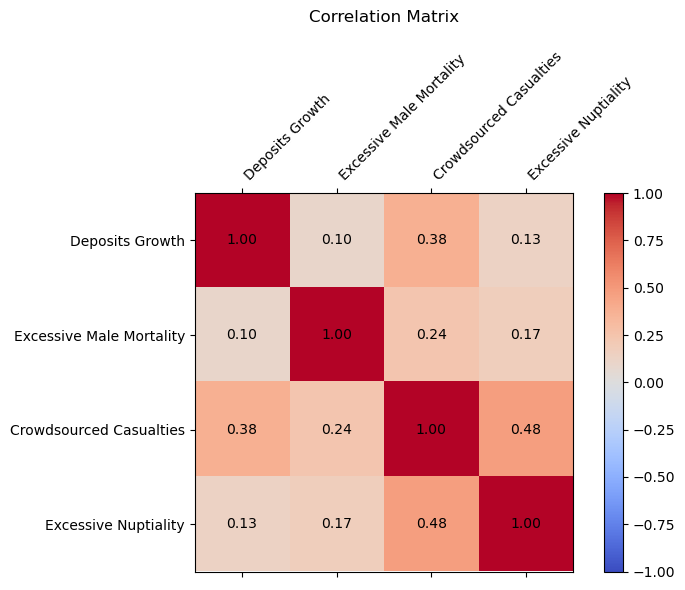

In [41]:
labels = df_selected.columns.tolist()
fig, ax = plt.subplots(figsize=(8, 6))

cax = ax.matshow(cormat, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='left')
ax.set_yticklabels(labels)

for (i, j), val in np.ndenumerate(cormat.values):
    ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()


# Casualties by category

In [42]:
rename_map = {
    "Total": "Total Casualties",
    "Volunteers": "Casualties among Volunteers",
    "Drafted": "Casualties among Drafted",
    "Prisoners": "Casualties among Prisoners",
    "PMC": "Casualties among PMC members",
}

df_selected = df_full[rename_map.keys()].rename(columns=rename_map)

cormat = df_selected.corr()


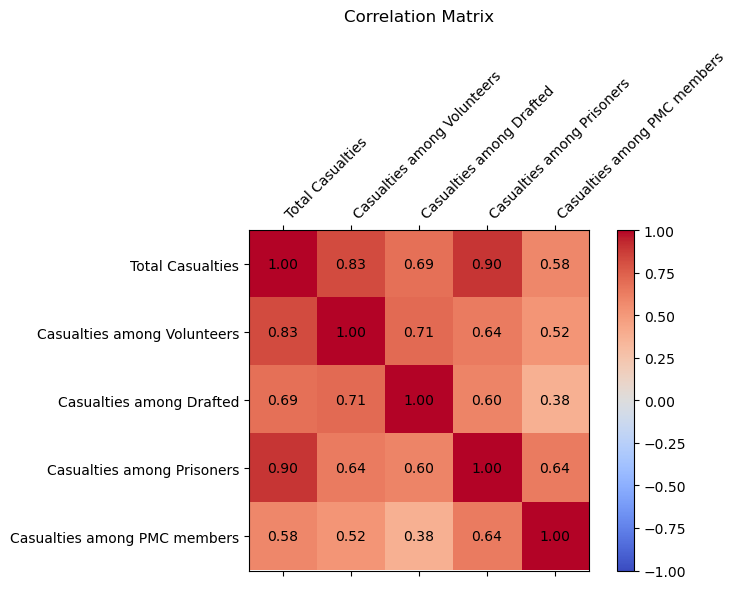

In [43]:
labels = df_selected.columns.tolist()
fig, ax = plt.subplots(figsize=(8, 6))

cax = ax.matshow(cormat, cmap='coolwarm', vmin=-1, vmax=1)
fig.colorbar(cax)

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='left')
ax.set_yticklabels(labels)

for (i, j), val in np.ndenumerate(cormat.values):
    ax.text(j, i, f"{val:.2f}", ha='center', va='center', color='black')

plt.title("Correlation Matrix", pad=20)
plt.tight_layout()
plt.show()


In [44]:
df_full.to_csv("intermediate/war_data.csv")